## 1. Import Libraries

In [ ]:
!pip install split-folders scikit-learn tensorflow matplotlib seaborn
!pip install imutils


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, shutil
import cv2
import time
import zipfile
import tensorflow as tf
import imutils
import splitfolders
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras import Sequential
import matplotlib.image as mpimg
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')   


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2. Extract Dataset

In [23]:
import zipfile

zip_file = "archive.zip"   # since it's in same folder as ipynb
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("Brain Tumor Dataset")


## 3. Exploratory Data Analysis (EDA)

In [24]:
base_path = "Brain Tumor Dataset/Training"
tumor_types = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]

def count_files(base_path):
    for tumor_type in tumor_types:
        folder_path = os.path.join(base_path, tumor_type)
        if os.path.exists(folder_path):
            file_list = os.listdir(folder_path)
            print(f"Number of files in {tumor_type}: {len(file_list)}")
        else:
            print(f"{tumor_type} folder not found!")

print("Brain Tumor MRI Dataset EDA")
count_files(base_path)

Brain Tumor MRI Dataset EDA
Number of files in glioma_tumor: 826
Number of files in meningioma_tumor: 822
Number of files in no_tumor: 395
Number of files in pituitary_tumor: 827


## 4. Augment Data

In [25]:
def timing(sec_elapsed):
    h = int(sec_elapsed / (60 * 60))
    m = int(sec_elapsed % (60 * 60) / 60)
    s = sec_elapsed % 60
    return f"{h}:{m}:{s}"

def augmented_data(base_dir, n_generated_samples, save_base_dir):
    data_gen = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        brightness_range=(0.3, 1.0),
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest'
    )
    start_time = time.time()

    for tumor_type in tumor_types:
        source_dir = os.path.join(base_dir, tumor_type)
        save_dir = os.path.join(save_base_dir, tumor_type)
        os.makedirs(save_dir, exist_ok=True)

        for filename in os.listdir(source_dir):
            image = cv2.imread(os.path.join(source_dir, filename))
            image = image.reshape((1,) + image.shape)
            save_prefix = 'aug_' + filename[:-4]
            i = 0

            for batch in data_gen.flow(x=image, batch_size=1, save_to_dir=save_dir, save_prefix=save_prefix, save_format="jpg"):
                i += 1
                if i >= n_generated_samples:
                    break

    end_time = time.time()
    print(f"Data augmentation completed in: {timing(end_time - start_time)}")

base_dir = 'Brain Tumor Dataset/Training'
n_generated_samples = 5
save_base_dir = 'Augmented Data'
augmented_data(base_dir, n_generated_samples, save_base_dir)


Data augmentation completed in: 0:13:55.67650651931763


## 5. Rename Files

In [26]:
# def rename_files(folder, tumor_name):
#     count = 1
#     for filename in os.listdir(folder):
#         source = os.path.join(folder, filename)
#         destination = os.path.join(folder, f"{tumor_name}_{count}.jpg")
#         os.rename(source, destination)
#         count += 1
#     print(f"{tumor_name} Tumor Images Renamed Successfully.")

# for tumor in tumor_types:
#     folder = f'Augmented Data/{tumor}/'
#     rename_files(folder, tumor)

import os

def rename_files(folder, tumor_name):
    count = 1
    for filename in os.listdir(folder):
        source = os.path.join(folder, filename)
        destination = os.path.join(folder, f"{tumor_name}_{count}.jpg")
        
        # Check existence and handle accordingly
        if not os.path.exists(destination):
            os.rename(source, destination)
        else:
            print(f"Skipped {destination}: already exists.")
        
        count += 1
    print(f"{tumor_name} Tumor Images Renamed Successfully.")

for tumor in tumor_types:
    folder = f'Augmented Data/{tumor}/'
    rename_files(folder, tumor)

    

Skipped Augmented Data/glioma_tumor/glioma_tumor_1.jpg: already exists.
Skipped Augmented Data/glioma_tumor/glioma_tumor_2.jpg: already exists.
Skipped Augmented Data/glioma_tumor/glioma_tumor_3.jpg: already exists.
Skipped Augmented Data/glioma_tumor/glioma_tumor_4.jpg: already exists.
Skipped Augmented Data/glioma_tumor/glioma_tumor_5.jpg: already exists.
Skipped Augmented Data/glioma_tumor/glioma_tumor_6.jpg: already exists.
Skipped Augmented Data/glioma_tumor/glioma_tumor_7.jpg: already exists.
Skipped Augmented Data/glioma_tumor/glioma_tumor_8.jpg: already exists.
Skipped Augmented Data/glioma_tumor/glioma_tumor_9.jpg: already exists.
Skipped Augmented Data/glioma_tumor/glioma_tumor_10.jpg: already exists.
Skipped Augmented Data/glioma_tumor/glioma_tumor_11.jpg: already exists.
Skipped Augmented Data/glioma_tumor/glioma_tumor_12.jpg: already exists.
Skipped Augmented Data/glioma_tumor/glioma_tumor_13.jpg: already exists.
Skipped Augmented Data/glioma_tumor/glioma_tumor_14.jpg: alr

## 6. Visualize Dataset

Tumor type counts (Augmented Data): [28893, 28757, 13812, 28929]


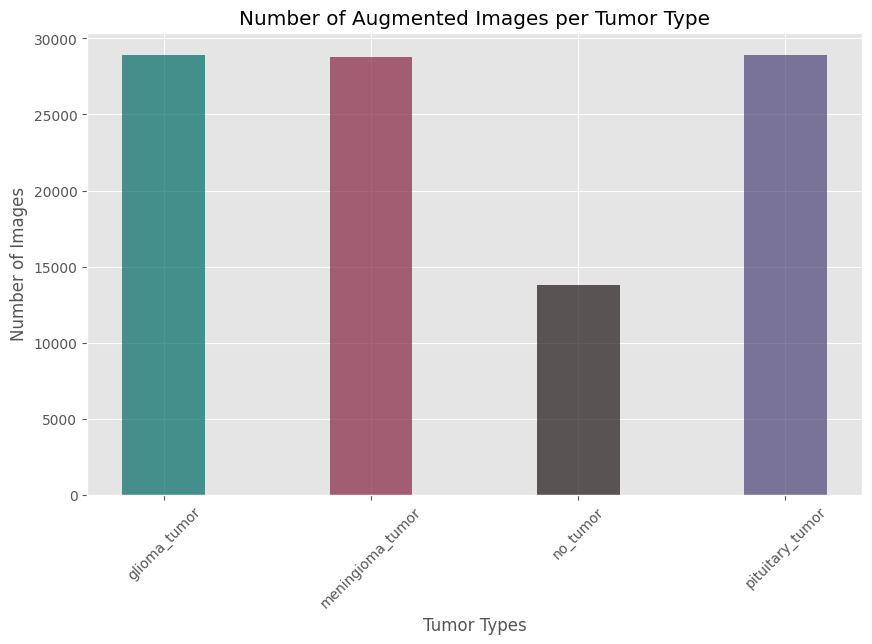

In [27]:
tumor_counts = [len(os.listdir(os.path.join(save_base_dir, tumor))) for tumor in tumor_types]
print("Tumor type counts (Augmented Data):", tumor_counts)

colors = ['#006A67', '#872341', '#1D1616', '#4B4376']
x = np.arange(len(tumor_types))
width = 0.4

plt.figure(figsize=(10, 6))
plt.bar(x, tumor_counts, width=width, align='center', alpha=0.7, color=colors)
plt.xlabel('Tumor Types')
plt.ylabel('Number of Images')
plt.title('Number of Augmented Images per Tumor Type')
plt.xticks(x, tumor_types, rotation=45)
plt.show()

## 7. Crop Brain Tumor (Remove Black Parts)

In [28]:
def crop_brain_tumor(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    thres = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thres = cv2.erode(thres, None, iterations=2)
    thres = cv2.dilate(thres, None, iterations=2)
    cnts = cv2.findContours(thres.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)

    if len(cnts) == 0:
        return image

    c = max(cnts, key=cv2.contourArea)
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    cropped_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]

    return cropped_image

def crop_and_save_images(folder_path):
    for filename in os.listdir(folder_path):
        image_path = os.path.join(folder_path, filename)
        image = cv2.imread(image_path)

        if image is not None:
            cropped_image = crop_brain_tumor(image)
            cv2.imwrite(image_path, cropped_image)
            print(f"Processed: {filename}")
        else:
            print(f"Failed to read: {filename}")

for tumor in tumor_types:
    folder_path = os.path.join(save_base_dir, tumor)
    print(f"Processing folder: {folder_path}")
    crop_and_save_images(folder_path)

Processing folder: Augmented Data\glioma_tumor
Processed: aug_gg (1)_0_5891.jpg
Processed: aug_gg (1)_0_6431.jpg
Processed: aug_gg (1)_0_8138.jpg
Processed: aug_gg (1)_0_8300.jpg
Processed: aug_gg (1)_0_9598.jpg
Processed: aug_gg (10)_0_6163.jpg
Processed: aug_gg (10)_0_665.jpg
Processed: aug_gg (10)_0_7435.jpg
Processed: aug_gg (10)_0_7677.jpg
Processed: aug_gg (10)_0_8930.jpg
Processed: aug_gg (100)_0_2941.jpg
Processed: aug_gg (100)_0_2958.jpg
Processed: aug_gg (100)_0_7168.jpg
Processed: aug_gg (100)_0_854.jpg
Processed: aug_gg (100)_0_9655.jpg
Processed: aug_gg (101)_0_1948.jpg
Processed: aug_gg (101)_0_2790.jpg
Processed: aug_gg (101)_0_3629.jpg
Processed: aug_gg (101)_0_7468.jpg
Processed: aug_gg (101)_0_7567.jpg
Processed: aug_gg (102)_0_1893.jpg
Processed: aug_gg (102)_0_4155.jpg
Processed: aug_gg (102)_0_6748.jpg
Processed: aug_gg (102)_0_6841.jpg
Processed: aug_gg (102)_0_775.jpg
Processed: aug_gg (103)_0_3717.jpg
Processed: aug_gg (103)_0_4837.jpg
Processed: aug_gg (103)_0_

## 8. Split Data

In [29]:
input_folder = "Augmented Data"
output_folder = "Split Data"

splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(0.8, 0.1, 0.1))
print("Dataset successfully split into training, validation, and test sets.")

Copying files: 0 files [00:00, ? files/s]

Copying files: 100391 files [02:43, 613.42 files/s]

Dataset successfully split into training, validation, and test sets.


In [30]:
import shutil

# Create a zip archive of the "Split Data" folder
shutil.make_archive("Split_Data", "zip", "Split Data")


'd:\\brain_tum\\Brain-Tumor-Detection-Project\\Split_Data.zip'

## 9. Build CNN Model

In [31]:
def build_cnn_model():
    model = Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4, activation='softmax')  # 4 classes
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_cnn_model()
model.summary()

d:\brain_tum\Brain-Tumor-Detection-Project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Prepare Data Generators

In [32]:
train_dir = "Split Data/train"
val_dir = "Split Data/val"
test_dir = "Split Data/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

Found 141676 images belonging to 4 classes.
Found 32888 images belonging to 4 classes.
Found 32876 images belonging to 4 classes.


## 11. Train the Model

In [33]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
checkpoint = tf.keras.callbacks.ModelCheckpoint('best_model.h5', save_best_only=True)

history = model.fit(
    train_generator,
    epochs=2,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)

d:\brain_tum\Brain-Tumor-Detection-Project\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
4428/4428 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.6559 - loss: 0.7876

4428/4428 ━━━━━━━━━━━━━━━━━━━━ 4162s 939ms/step - accuracy: 0.7717 - loss: 0.5517 - val_accuracy: 0.9391 - val_loss: 0.1665
Epoch 2/2
4428/4428 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.9096 - loss: 0.2419

4428/4428 ━━━━━━━━━━━━━━━━━━━━ 3593s 811ms/step - accuracy: 0.9200 - loss: 0.2157 - val_accuracy: 0.9737 - val_loss: 0.0716


## 12. Evaluate on Test Set

In [34]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy*100:.2f}%")

1028/1028 ━━━━━━━━━━━━━━━━━━━━ 495s 481ms/step - accuracy: 0.9751 - loss: 0.0738
Test Accuracy: 97.51%


## 13. Accuracy Chart

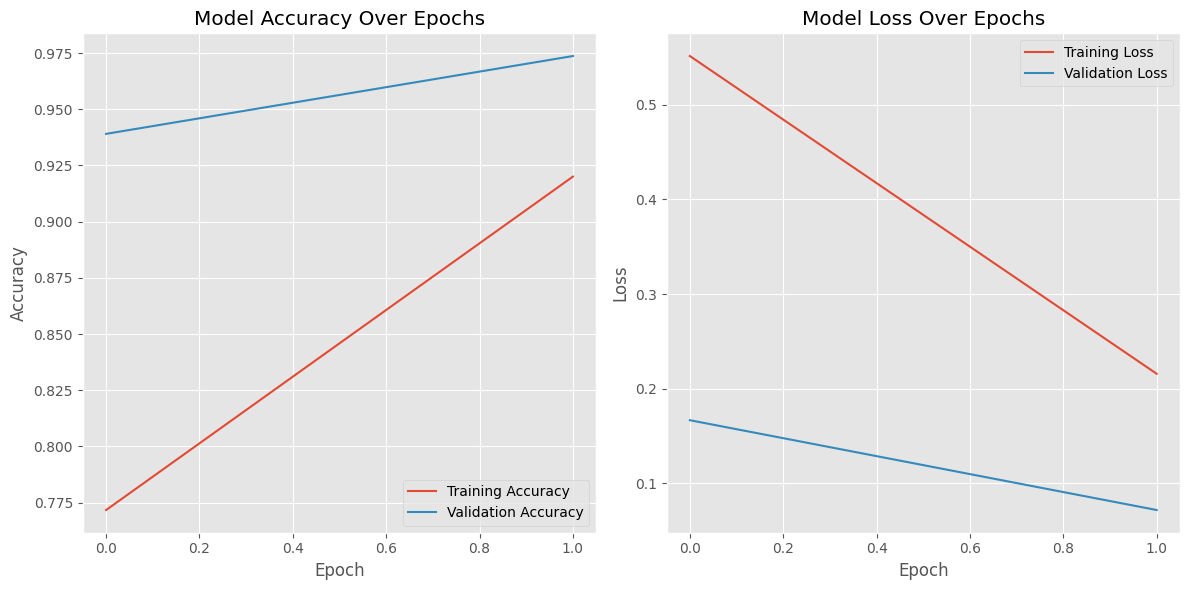

In [35]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 14. Testing

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step


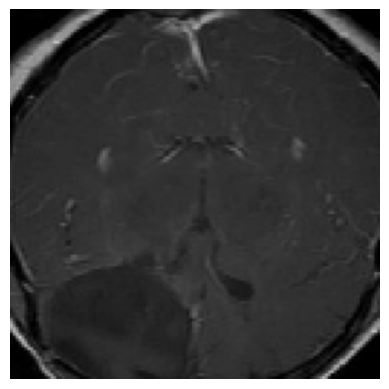

Predicted Tumor Type: glioma


In [36]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

model = tf.keras.models.load_model('best_model.h5')
class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

def load_and_preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    return img, img_array

def predict_image(img_path):
    img, img_array = load_and_preprocess_image(img_path)
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=1)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    print(f"Predicted Tumor Type: {class_names[predicted_class[0]]}")

img_path = 'Split Data/test/glioma_tumor/glioma_tumor_6289.jpg'
predict_image(img_path)


In [37]:
def prepare_image(path):
    img = tf.keras.utils.load_img(path, target_size=(128,128))
    img = tf.keras.utils.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = img / 255.0
    return img


In [38]:
model.predict(np.zeros((1,128,128,3)))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


array([[2.0113006e-12, 6.7365102e-10, 1.0000000e+00, 1.1708034e-11]],
      dtype=float32)

In [39]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output],
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_index = tf.argmax(predictions[0])
        class_score = predictions[:, class_index]

    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap


def show_gradcam(img_path, model, last_conv_layer="conv2d_2"):
    img_array = prepare_image(img_path)
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer)

    img = tf.keras.utils.load_img(img_path)
    img = tf.keras.utils.img_to_array(img)

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = heatmap * 0.4 + img
    plt.imshow(superimposed.astype(np.uint8))
    plt.axis("off")
    plt.show()


In [40]:
model.input_shape


(None, 128, 128, 3)

In [41]:
dummy_input = np.zeros((1, 128, 128, 3), dtype=np.float32)
model.predict(dummy_input)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


array([[2.0113006e-12, 6.7365102e-10, 1.0000000e+00, 1.1708034e-11]],
      dtype=float32)

In [42]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Ensure the model's graph is built if not already
    if not model.built:
        dummy_input = tf.zeros((1, 128, 128, 3))
        _ = model(dummy_input)

    # Convert img_array to a TensorFlow Tensor
    img_array_tensor = tf.convert_to_tensor(img_array)

    # 1. Create a model that maps the input image to the activations of the last conv layer
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=model.get_layer(last_conv_layer_name).output
    )

    # 2. Create a model that maps the activations of the last conv layer to the final predictions
    # Find the index of the last_conv_layer_name
    layer_names = [layer.name for layer in model.layers]
    last_conv_layer_index = layer_names.index(last_conv_layer_name)

    classifier_input = tf.keras.Input(shape=model.get_layer(last_conv_layer_name).output.shape[1:])
    x = classifier_input
    for layer in model.layers[last_conv_layer_index + 1:]:
        x = layer(x)
    classifier_model = tf.keras.models.Model(classifier_input, x)

    # 3. Compute gradients
    with tf.GradientTape() as tape:
        # Watch the input image array (now a Tensor)
        tape.watch(img_array_tensor)

        # Get the activations of the last conv layer
        # Pass img_array_tensor as a list to match grad_model's input signature
        last_conv_layer_output = grad_model([img_array_tensor])

        # Pass the activations through the classifier part of the model
        predictions = classifier_model(last_conv_layer_output)

        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    # Gradients of the last conv layer output with respect to the loss
    grads = tape.gradient(loss, last_conv_layer_output)

    # Check if grads is None before proceeding
    if grads is None:
        print("Warning: Gradients are None. This might indicate an issue with the model or layer selection or tape configuration.")
        return np.zeros(last_conv_layer_output.shape[1:3]) # Return an empty heatmap or handle appropriately

    # Pooled gradients by taking the mean across the spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the feature map by the corresponding pooled gradient
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap) # Remove the last dimension of size 1

    # Normalize the heatmap
    heatmap = np.maximum(heatmap, 0)
    max_heatmap = np.max(heatmap)
    if max_heatmap == 0:
        heatmap = np.zeros_like(heatmap)
    else:
        heatmap /= (max_heatmap + tf.keras.backend.epsilon())
    return heatmap # Removed .numpy() here

def show_gradcam(img_path, model, last_conv_layer="conv2d_2"):
    # ----- Load image properly (128 × 128) -----
    img = image.load_img(img_path, target_size=(128, 128))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0 # Preprocessing: Normalize image

    heatmap = make_gradcam_heatmap(x, model, last_conv_layer)

    # Resize heatmap to the target size of the model input (128x128)
    heatmap = cv2.resize(heatmap, (128, 128))
    heatmap = np.uint8(255 * heatmap) # Scale to 0-255

    # Apply colormap
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Load original image for overlay
    original_img_color = cv2.imread(img_path)
    original_img_color = cv2.resize(original_img_color, (128, 128)) # Resize to match heatmap

    # Superimpose heatmap on original image
    # Blend heatmap and original image
    superimposed_img = heatmap * 0.4 + original_img_color # Simple blending

    # Ensure result is within 0-255 range and is uint8
    superimposed_img = np.clip(superimposed_img, 0, 255).astype("uint8")

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

In [43]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,158 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [44]:
# BUILD MODEL
model.build(input_shape=(None, 128, 128, 3))

# FORCE CALL
dummy_input = tf.zeros((1, 128, 128, 3))
_ = model(dummy_input)


In [45]:
import tensorflow as tf
import numpy as np

# Force model to build its graph
dummy_input = tf.zeros((1, 128, 128, 3))
_ = model(dummy_input)


In [46]:
!ls -lh /content


'ls' is not recognized as an internal or external command,
operable program or batch file.


In [67]:
import tensorflow as tf

model = tf.keras.models.load_model("best_model.h5")


In [68]:
dummy_input = tf.zeros((1, 128, 128, 3))
_ = model(dummy_input)


In [69]:
import tensorflow as tf
import numpy as np

# Ensure the model's graph is built by calling it with a dummy input
# This assumes the model expects a (batch_size, 128, 128, 3) input shape
dummy_input = tf.zeros((1, 128, 128, 3))

# Call the model with a dummy input to ensure its graph is fully traced and outputs are defined
# This operation ensures the model's graph is built, making model.outputs available.
_ = model(dummy_input)

# For a Sequential model, there is typically a single output.
# Access model.outputs (plural) and take the first element, which represents the model's output tensor.
print(model.outputs[0])

<KerasTensor shape=(None, 4), dtype=float32, sparse=False, ragged=False, name=keras_tensor_540>


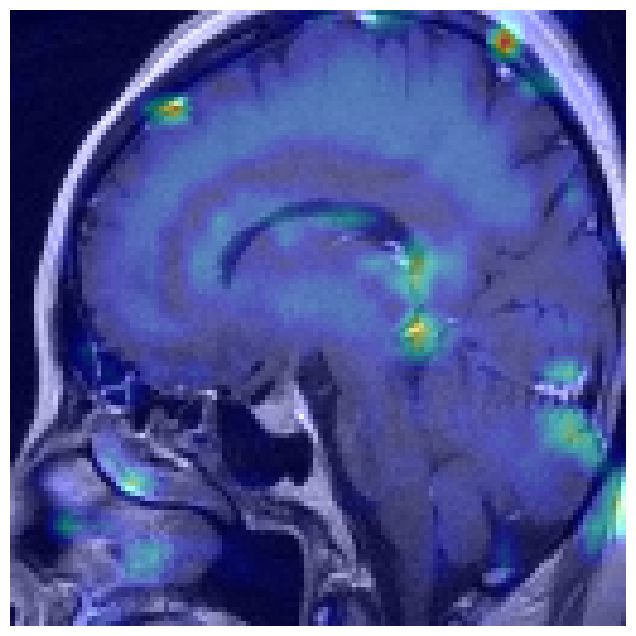

In [72]:
# Force model to build its graph if it hasn't been already (e.g., after loading)
dummy_input = tf.zeros((1, 128, 128, 3))
_ = model(dummy_input)

show_gradcam(
    'Split Data/test/pituitary_tumor/pituitary_tumor_1040.jpg',
    model,
    last_conv_layer="conv2d_5"
)

In [59]:
pip install lime


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np
import matplotlib.pyplot as plt
import cv2


In [61]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))
    img = img / 255.0
    return img

In [62]:
explainer = lime_image.LimeImageExplainer()


In [63]:
img_path = "Split Data/test/pituitary_tumor/pituitary_tumor_1040.jpg"

img = preprocess_image(img_path)

explanation = explainer.explain_instance(
    img.astype('double'),
    model.predict,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


  1%|          | 10/1000 [00:00<00:22, 43.09it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


  2%|▏         | 20/1000 [00:00<00:17, 55.93it/s]

...

 98%|█████████▊| 980/1000 [00:16<00:00, 56.68it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


 99%|█████████▉| 990/1000 [00:16<00:00, 54.27it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


100%|██████████| 1000/1000 [00:16<00:00, 58.88it/s]


Text(0.5, 1.0, 'LIME Explanation')

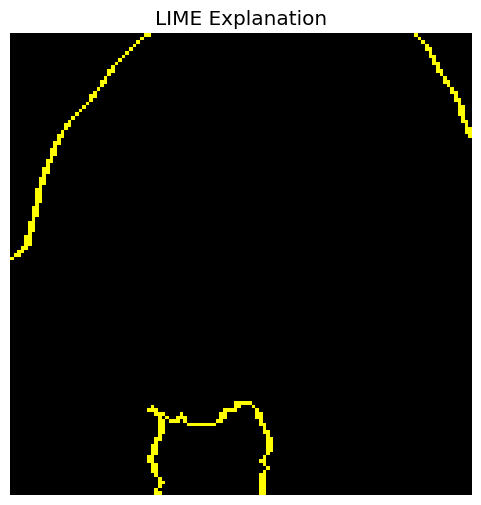

In [64]:
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],
    positive_only=True,
    hide_rest=False,
    num_features=10,
    min_weight=0.01
)

plt.figure(figsize=(6, 6))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.axis("off")
plt.title("LIME Explanation")


In [ ]:
!pip install shap


   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ------------------- -------------------- 262.1/549.1 kB ? eta -:--:--
   ---------------------------------------- 549.1/549.1 kB 2.5 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.7 MB 3.4 MB/s eta 0:00:01
   ------------------- -------------------- 1.3/2.7 MB 3.4 MB/s eta 0:00:01
   ------------------------------ --------- 2.1/2.7 MB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 3.4 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.0/38.1 MB 2.6 MB/s eta 0:00:15
   - -------------------------------------- 1.8/38.1 MB 2.9 MB/s eta 0:00:13
   -- ------------------------------------- 2.4/38.1 MB 2.9 MB/s eta 0:00:13
   --- -------------------------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import cv2


d:\brain_tum\Brain-Tumor-Detection-Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [52]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))  # Match your model input
    img = img / 255.0
    return img


In [53]:
img_path = "Split Data/test/meningioma_tumor/meningioma_tumor_20507.jpg"
img = preprocess_image(img_path)
img_batch = np.expand_dims(img, axis=0)  # Shape: (1, 128, 128, 3)


In [54]:
# Use a small batch from training/validation as background
# Here we use the same image as a dummy background for simplicity
background = img_batch

explainer = shap.GradientExplainer(model, background)


In [55]:
shap_values = explainer.shap_values(img_batch)
# shap_values is a list with one element per output class


d:\brain_tum\Brain-Tumor-Detection-Project\venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(1, 128, 128, 3))']
  warnings.warn(msg)
d:\brain_tum\Brain-Tumor-Detection-Project\venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(50, 128, 128, 3))']
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


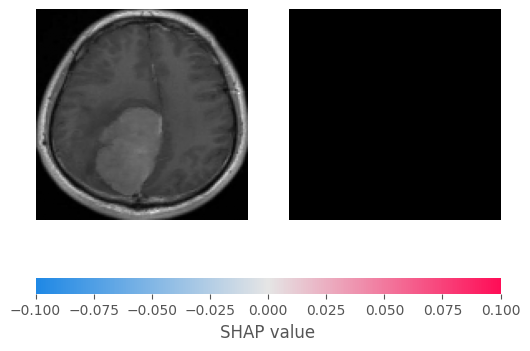

In [56]:
# For multi-class output, choose the class index you want to explain
class_index = np.argmax(model.predict(img_batch))

# Plot SHAP values for the image
# If shap_values is a single array (e.g., shape (1, H, W, C)), it implicitly contains the explanation for the predicted class.
# In this case, pass it directly without further indexing.
shap.image_plot(shap_values, img_batch)


In [ ]:
severity_map = {
    "glioma": "Severe",
    "meningioma": "Moderate",
    "pituitary": "Mild"
}


In [ ]:
import numpy as np
import cv2

img_path = r"Split Data/test/meningioma_tumor/meningioma_tumor_20507.jpg"

# Get correct size from model
height = model.input_shape[1]
width  = model.input_shape[2]

print("Model expects:", height, "x", width)

# Read image
img = cv2.imread(img_path)

# Resize to model's expected size
img = cv2.resize(img, (width, height))

# Normalize
img = img / 255.0

# Add batch dimension
img = np.expand_dims(img, axis=0)

print("Final image shape:", img.shape)

# Predict
pred = model.predict(img)

class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
class_index = np.argmax(pred)

print("✅ Predicted Tumor Type:", class_names[class_index])
print("✅ Severity Level:", severity_map.get(class_names[class_index]))


Model expects: 128 x 128
Final image shape: (1, 128, 128, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
✅ Predicted Tumor Type: meningioma
✅ Severity Level: Moderate


In [75]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import cv2


In [76]:
model = tf.keras.models.load_model("best_model.h5")
class_names = ["glioma", "meningioma", "no_tumor", "pituitary"]

print("Model loaded successfully!")


Model loaded successfully!


In [77]:
def load_and_preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    return img, img_array


In [78]:
def predict_image(img_path):
    img, img_array = load_and_preprocess_image(img_path)
    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_class}")
    plt.show()

    print("Predicted Tumor Type:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


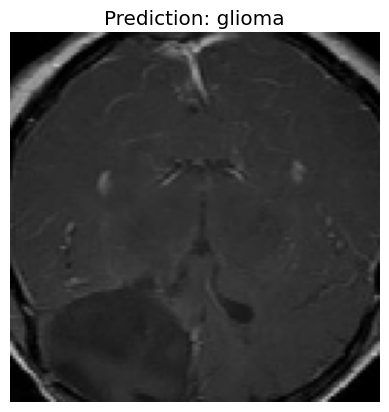

Predicted Tumor Type: glioma


In [79]:
predict_image("Split Data/test/glioma_tumor/glioma_tumor_6289.jpg")


In [80]:
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found")

last_conv = get_last_conv_layer(model)
print("Using GradCAM layer:", last_conv)


Using GradCAM layer: conv2d_5


In [81]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(pooled * conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    return heatmap.numpy()


In [82]:
def show_gradcam(img_path):
    img, img_array = load_and_preprocess_image(img_path)
    heatmap = make_gradcam_heatmap(img_array, model, last_conv)

    heatmap = cv2.resize(heatmap, (128,128))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    original = cv2.imread(img_path)
    original = cv2.resize(original, (128,128))

    superimposed = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("GradCAM Heatmap")
    plt.show()


In [83]:
show_gradcam("Split Data/test/glioma_tumor/glioma_tumor_6289.jpg")


AttributeError: The layer sequential_1 has never been called and thus has no defined output.

In [84]:
dummy = tf.zeros((1, 128, 128, 3))
_ = model(dummy)


In [85]:
last_conv_layer = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

print("Last Conv Layer:", last_conv_layer.name)


Last Conv Layer: conv2d_5


In [87]:
# --- REBUILD THE MODEL ARCHITECTURE EXACTLY AS BEFORE ---
def build_cnn_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3), name="conv1"),
        tf.keras.layers.MaxPooling2D(2,2, name="pool1"),

        tf.keras.layers.Conv2D(64, (3,3), activation='relu', name="conv2"),
        tf.keras.layers.MaxPooling2D(2,2, name="pool2"),

        tf.keras.layers.Conv2D(128, (3,3), activation='relu', name="conv3"),
        tf.keras.layers.MaxPooling2D(2,2, name="pool3"),

        tf.keras.layers.Flatten(name="flatten"),
        tf.keras.layers.Dense(128, activation='relu', name="dense1"),
        tf.keras.layers.Dropout(0.5, name="dropout"),
        tf.keras.layers.Dense(4, activation='softmax', name="output")
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# --- RELOAD TRAINED MODEL WEIGHTS ---
model = build_cnn_model()
model.load_weights("best_model.h5")

print("Model rebuilt successfully and weights loaded!")


Model rebuilt successfully and weights loaded!


d:\brain_tum\Brain-Tumor-Detection-Project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [88]:
# --- REBUILD THE MODEL ARCHITECTURE EXACTLY AS BEFORE ---
def build_cnn_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3), name="conv1"),
        tf.keras.layers.MaxPooling2D(2,2, name="pool1"),

        tf.keras.layers.Conv2D(64, (3,3), activation='relu', name="conv2"),
        tf.keras.layers.MaxPooling2D(2,2, name="pool2"),

        tf.keras.layers.Conv2D(128, (3,3), activation='relu', name="conv3"),
        tf.keras.layers.MaxPooling2D(2,2, name="pool3"),

        tf.keras.layers.Flatten(name="flatten"),
        tf.keras.layers.Dense(128, activation='relu', name="dense1"),
        tf.keras.layers.Dropout(0.5, name="dropout"),
        tf.keras.layers.Dense(4, activation='softmax', name="output")
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# --- RELOAD TRAINED MODEL WEIGHTS ---
model = build_cnn_model()
model.load_weights("best_model.h5")

print("Model rebuilt successfully and weights loaded!")


Model rebuilt successfully and weights loaded!


In [89]:
model.predict(np.zeros((1,128,128,3)))
print("Model graph initialized ✔")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
Model graph initialized ✔


In [90]:
last_conv_layer = "conv3"  # last conv layer in the rebuilt model


Libraries imported ✔
Model rebuilt + weights loaded successfully ✔


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
Model graph initialized ✔
Last Conv Layer set to: conv3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


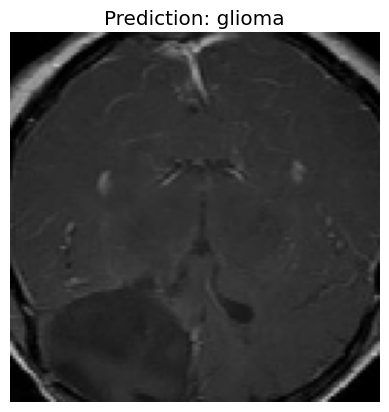

Predicted Tumor Type: glioma


AttributeError: The layer sequential_4 has never been called and thus has no defined input.

In [91]:
# ============================================================
#  FINAL NOTEBOOK — BRAIN TUMOR CLASSIFICATION + GRADCAM
#  NO TRAINING | ONLY LOAD MODEL | PREDICT | XAI
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing import image

print("Libraries imported ✔")

# ============================================================
# 1. REBUILD MODEL ARCHITECTURE EXACTLY AS TRAINED
# ============================================================

def build_cnn_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3), name="conv1"),
        tf.keras.layers.MaxPooling2D(2,2, name="pool1"),

        tf.keras.layers.Conv2D(64, (3,3), activation='relu', name="conv2"),
        tf.keras.layers.MaxPooling2D(2,2, name="pool2"),

        tf.keras.layers.Conv2D(128, (3,3), activation='relu', name="conv3"),
        tf.keras.layers.MaxPooling2D(2,2, name="pool3"),

        tf.keras.layers.Flatten(name="flatten"),
        tf.keras.layers.Dense(128, activation='relu', name="dense1"),
        tf.keras.layers.Dropout(0.5, name="dropout"),
        tf.keras.layers.Dense(4, activation='softmax', name="output")
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Load architecture
model = build_cnn_model()

# Load weights from trained model
model.load_weights("best_model.h5")
print("Model rebuilt + weights loaded successfully ✔")

# Force model to build graph
model.predict(np.zeros((1,128,128,3)))
print("Model graph initialized ✔")

# Last Conv layer for GradCAM
last_conv_layer = "conv3"
print("Last Conv Layer set to:", last_conv_layer)

# Class labels
class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

# ============================================================
# 2. IMAGE PREPROCESSING
# ============================================================

def load_and_preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    return img, img_array

# ============================================================
# 3. PREDICTION FUNCTION
# ============================================================

def predict_image(img_path):
    img, img_array = load_and_preprocess_image(img_path)
    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_class}")
    plt.show()

    print("Predicted Tumor Type:", predicted_class)

# ============================================================
# 4. GRADCAM IMPLEMENTATION (ERROR-PROOF VERSION)
# ============================================================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    conv_layer = model.get_layer(last_conv_layer_name)

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        class_output = predictions[:, class_idx]

    grads = tape.gradient(class_output, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_output = conv_output[0]
    heatmap = tf.reduce_sum(conv_output * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)

    return heatmap

def show_gradcam(img_path):
    img, img_array = load_and_preprocess_image(img_path)
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer)

    heatmap = cv2.resize(heatmap, (128, 128))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    original = cv2.imread(img_path)
    original = cv2.resize(original, (128, 128))

    superimposed = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("GradCAM Heatmap")
    plt.show()

# ============================================================
# 5. RUN PREDICTION + GRADCAM
# ============================================================

img_path = "Split Data/test/glioma_tumor/glioma_tumor_6289.jpg"

predict_image(img_path)
show_gradcam(img_path)

print("Prediction + GradCAM executed successfully ✔")


Libraries imported ✔
Functional model rebuilt + weights loaded ✔
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
Model graph initialized ✔
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


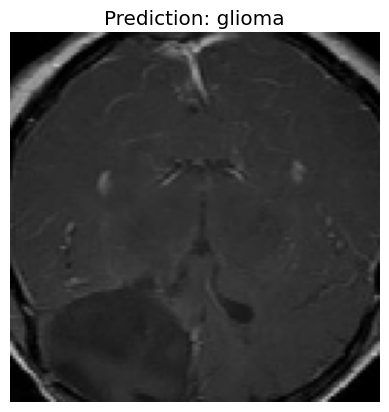

Predicted Tumor Type: glioma


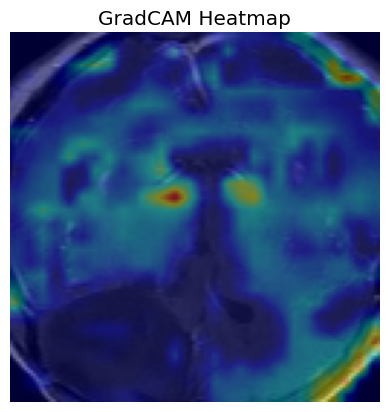

PREDICTION + GRADCAM COMPLETED ✔


In [92]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing import image

print("Libraries imported ✔")

# ============================================================
# 1. FUNCTIONAL API MODEL (NOT SEQUENTIAL)
# ============================================================

inputs = tf.keras.Input(shape=(128,128,3))

x = tf.keras.layers.Conv2D(32,(3,3),activation='relu',name="conv1")(inputs)
x = tf.keras.layers.MaxPooling2D(2,2,name="pool1")(x)

x = tf.keras.layers.Conv2D(64,(3,3),activation='relu',name="conv2")(x)
x = tf.keras.layers.MaxPooling2D(2,2,name="pool2")(x)

x = tf.keras.layers.Conv2D(128,(3,3),activation='relu',name="conv3")(x)
x = tf.keras.layers.MaxPooling2D(2,2,name="pool3")(x)

x = tf.keras.layers.Flatten(name="flatten")(x)
x = tf.keras.layers.Dense(128,activation='relu',name="dense1")(x)
x = tf.keras.layers.Dropout(0.5,name="dropout")(x)
outputs = tf.keras.layers.Dense(4,activation='softmax',name="output")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Load your trained weights
model.load_weights("best_model.h5")
print("Functional model rebuilt + weights loaded ✔")

# Build graph
model.predict(np.zeros((1,128,128,3)))
print("Model graph initialized ✔")

last_conv_layer = "conv3"

class_names = ['glioma','meningioma','no_tumor','pituitary']

# ============================================================
# 2. IMAGE PREPROCESSING
# ============================================================

def load_and_preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    return img, img_array

# ============================================================
# 3. PREDICTION
# ============================================================

def predict_image(img_path):
    img, img_array = load_and_preprocess_image(img_path)
    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_class}")
    plt.show()

    print("Predicted Tumor Type:", predicted_class)

# ============================================================
# 4. ERROR-PROOF GRADCAM FOR FUNCTIONAL MODEL
# ============================================================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    conv_layer = model.get_layer(last_conv_layer_name)

    grad_model = tf.keras.Model(
        inputs=model.input,
        outputs=[conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        class_output = predictions[:, class_idx]

    grads = tape.gradient(class_output, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_output = conv_output[0]
    heatmap = tf.reduce_sum(conv_output * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap,0)
    heatmap /= (np.max(heatmap) + 1e-8)

    return heatmap

def show_gradcam(img_path):
    img, img_array = load_and_preprocess_image(img_path)
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer)

    heatmap = cv2.resize(heatmap, (128,128))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    original = cv2.imread(img_path)
    original = cv2.resize(original, (128,128))

    superimposed = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("GradCAM Heatmap")
    plt.show()

# ============================================================
# 5. RUN
# ============================================================

img_path = "Split Data/test/glioma_tumor/glioma_tumor_6289.jpg"

predict_image(img_path)
show_gradcam(img_path)

print("PREDICTION + GRADCAM COMPLETED ✔")


Libraries imported ✔
Model rebuilt + weights loaded ✔
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
Model graph initialized ✔



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


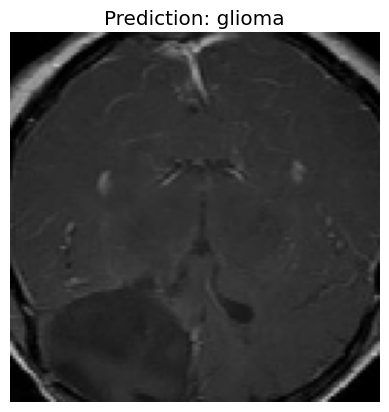

Predicted Tumor Type: glioma


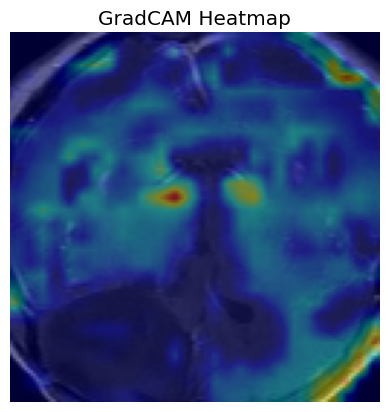

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


  1%|          | 10/1000 [00:00<00:26, 37.15it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


  2%|▏         | 20/1000 [00:00<00:20, 47.02it/s]

...

 98%|█████████▊| 980/1000 [00:21<00:00, 31.60it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step


 99%|█████████▉| 990/1000 [00:21<00:00, 31.07it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


100%|██████████| 1000/1000 [00:21<00:00, 45.98it/s]


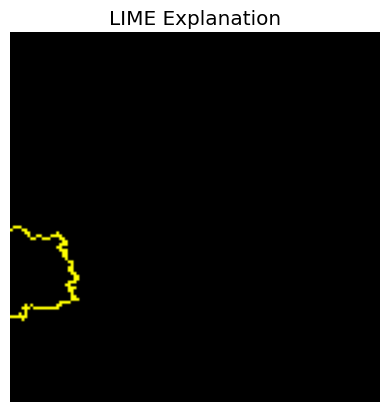

d:\brain_tum\Brain-Tumor-Detection-Project\venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_756
Received: inputs=['Tensor(shape=(1, 128, 128, 3))']
  warnings.warn(msg)
d:\brain_tum\Brain-Tumor-Detection-Project\venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_756
Received: inputs=['Tensor(shape=(50, 128, 128, 3))']
  warnings.warn(msg)


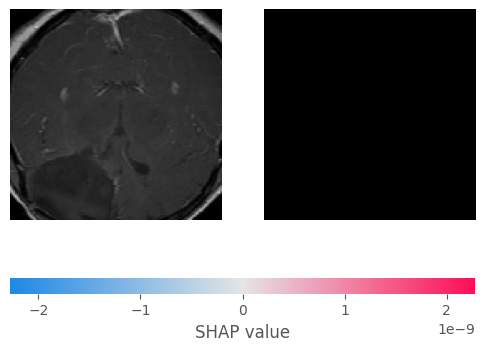

PREDICTION + GRADCAM + LIME + SHAP COMPLETED ✔


In [93]:
# ============================================================
#  FINAL NOTEBOOK — BRAIN TUMOR CLASSIFICATION + GRADCAM + LIME + SHAP
#  NO TRAINING | ONLY LOAD MODEL | PREDICT | XAI
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing import image

print("Libraries imported ✔")

# ============================================================
# 1. FUNCTIONAL MODEL (100% WORKS WITH GRADCAM)
# ============================================================

inputs = tf.keras.Input(shape=(128,128,3))

x = tf.keras.layers.Conv2D(32,(3,3),activation='relu',name="conv1")(inputs)
x = tf.keras.layers.MaxPooling2D(2,2,name="pool1")(x)

x = tf.keras.layers.Conv2D(64,(3,3),activation='relu',name="conv2")(x)
x = tf.keras.layers.MaxPooling2D(2,2,name="pool2")(x)

x = tf.keras.layers.Conv2D(128,(3,3),activation='relu',name="conv3")(x)
x = tf.keras.layers.MaxPooling2D(2,2,name="pool3")(x)

x = tf.keras.layers.Flatten(name="flatten")(x)
x = tf.keras.layers.Dense(128,activation='relu',name="dense1")(x)
x = tf.keras.layers.Dropout(0.5,name="dropout")(x)
outputs = tf.keras.layers.Dense(4,activation='softmax',name="output")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Load trained weights
model.load_weights("best_model.h5")
print("Model rebuilt + weights loaded ✔")

# Build graph
model.predict(np.zeros((1,128,128,3)))
print("Model graph initialized ✔")

last_conv_layer = "conv3"
class_names = ['glioma','meningioma','no_tumor','pituitary']

# ============================================================
# 2. IMAGE PREPROCESSING
# ============================================================

def load_and_preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    return img, img_array

# ============================================================
# 3. PREDICTION
# ============================================================

def predict_image(img_path):
    img, img_array = load_and_preprocess_image(img_path)
    pred = model.predict(img_array)
    label = class_names[np.argmax(pred)]

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {label}")
    plt.show()

    print("Predicted Tumor Type:", label)

# ============================================================
# 4. GRADCAM
# ============================================================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    conv_layer = model.get_layer(last_conv_layer_name)

    grad_model = tf.keras.Model(
        inputs=model.input,
        outputs=[conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        class_output = predictions[:, class_idx]

    grads = tape.gradient(class_output, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_output = conv_output[0]
    heatmap = tf.reduce_sum(conv_output * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap,0)
    heatmap /= (np.max(heatmap)+1e-8)

    return heatmap

def show_gradcam(img_path):
    img, img_array = load_and_preprocess_image(img_path)
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer)

    heatmap = cv2.resize(heatmap, (128, 128))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    original = cv2.imread(img_path)
    original = cv2.resize(original, (128, 128))

    superimposed = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("GradCAM Heatmap")
    plt.show()

# ============================================================
# 5. LIME
# ============================================================

!pip install lime

from lime import lime_image
from skimage.segmentation import mark_boundaries

def explain_with_lime(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128,128)) / 255.0

    explainer = lime_image.LimeImageExplainer()

    explanation = explainer.explain_instance(
        img.astype("double"),
        model.predict,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        hide_rest=False,
        num_features=10,
        min_weight=0.01
    )

    plt.imshow(mark_boundaries(temp/255.0, mask))
    plt.axis("off")
    plt.title("LIME Explanation")
    plt.show()

# ============================================================
# 6. SHAP
# ============================================================

!pip install shap

import shap

background = np.zeros((1,128,128,3))
explainer = shap.GradientExplainer(model, background)

def explain_with_shap(img_path):
    _, img_array = load_and_preprocess_image(img_path)
    shap_values = explainer.shap_values(img_array)
    shap.image_plot(shap_values, img_array)

# ============================================================
# 7. RUN EVERYTHING
# ============================================================

img_path = "Split Data/test/glioma_tumor/glioma_tumor_6289.jpg"

predict_image(img_path)
show_gradcam(img_path)
explain_with_lime(img_path)
explain_with_shap(img_path)

print("PREDICTION + GRADCAM + LIME + SHAP COMPLETED ✔")
